<a href="https://colab.research.google.com/github/Raditya-Z/MachineLearning_244107020144/blob/main/JS-04/JS-04_TugasPraktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum
## 1. Tugas K-Means

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [6]:
from google.colab import files
uploaded = files.upload() # upload dataset

Saving Mall_Customers.csv to Mall_Customers.csv


In [7]:
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)

> Saya memilih fitur Annual Income (k$) dan Spending Score (1-100) karena kedua fitur tersebut dapat digunakan untuk mengelompokkan pelanggan berdasarkan tingkat pendapatan dan perilaku belanjanya.

In [8]:
X = df.iloc[:, 3:5]

3. Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik.

In [9]:
sse = []

K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

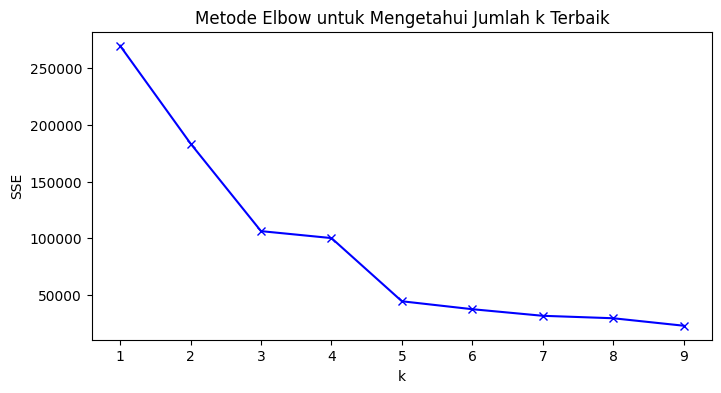

In [10]:
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

> Titik elbow berada pada k = 5 karena setelah k = 5 penurunan SSE mulai melandai atau tidak sebesar sebelumnya.

In [13]:
cl_kmeans = KMeans(n_clusters=5)
y_kmeans = cl_kmeans.fit_predict(X)

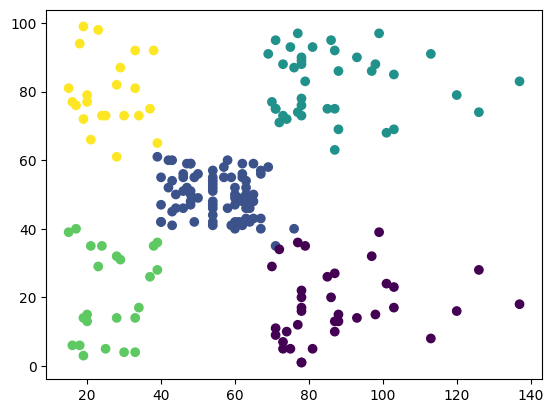

In [14]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_kmeans)

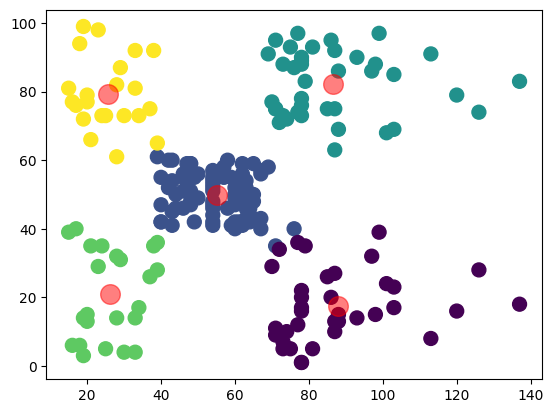

In [16]:
plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y_kmeans,
    s=100
)

centers = cl_kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    alpha=0.5
)

plt.show()

In [17]:
print(centers)

[[87.75       17.58333333]
 [55.0875     49.7125    ]
 [86.53846154 82.12820513]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]]


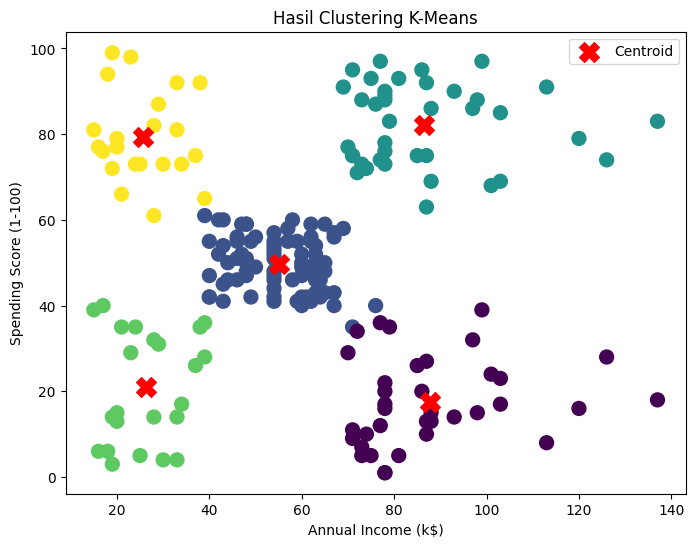

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y_kmeans,
    s=100
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroid'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hasil Clustering K-Means')
plt.legend()
plt.show()

> Berdasarkan metode Elbow, jumlah cluster terbaik adalah 5 karena pada grafik terlihat bahwa penurunan nilai SSE cukup besar hingga k = 5, sedangkan setelah k = 5 penurunannya mulai melandai. Hasil K-Means kemudian membagi pelanggan menjadi 5 kelompok berdasarkan fitur Annual Income dan Spending Score.

# 2. Tugas DBSCAN
## 1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.

In [21]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import numpy as np

X, labels_true = make_moons(
    n_samples=1000, noise=0.05, random_state=0
)

X = StandardScaler().fit_transform(X)

()

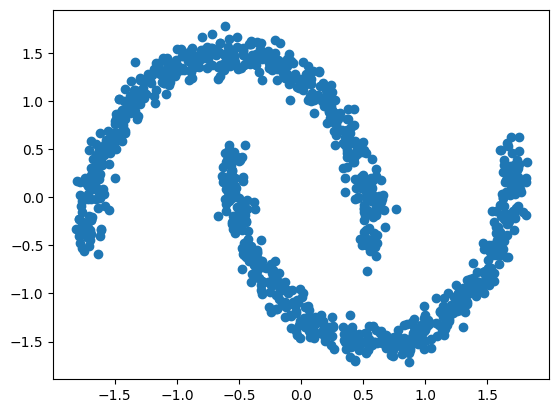

In [22]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1]);
()

## 2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise

In [23]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


## 3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.

In [24]:
from sklearn import metrics

print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


## 4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).

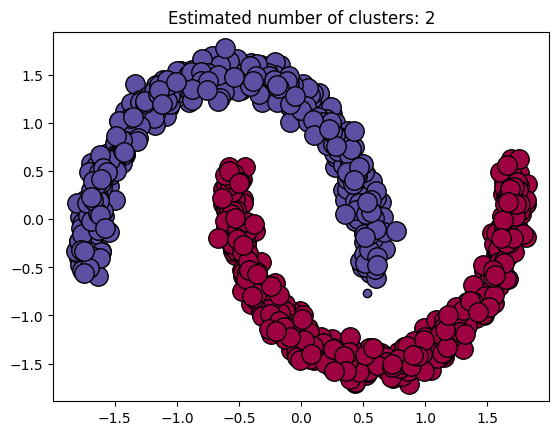

In [25]:
unique_labels = set(labels)

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

## 5. Lakukan eksperimen:

- eps = 0.05, 0.1, 0.3, 0.5

In [26]:
eps_values = [0.05, 0.1, 0.3, 0.5]

for eps in eps_values:
    db_test = DBSCAN(eps=eps, min_samples=5).fit(X)
    labels_test = db_test.labels_

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)

    print("eps =", eps)
    print("Jumlah cluster =", n_clusters)
    print("Jumlah noise =", n_noise)
    print()

eps = 0.05
Jumlah cluster = 51
Jumlah noise = 444

eps = 0.1
Jumlah cluster = 3
Jumlah noise = 21

eps = 0.3
Jumlah cluster = 2
Jumlah noise = 0

eps = 0.5
Jumlah cluster = 1
Jumlah noise = 0



In [27]:
eps_values = [0.05, 0.1, 0.3, 0.5]

for eps in eps_values:
    db_test = DBSCAN(eps=eps, min_samples=5).fit(X)
    labels_test = db_test.labels_

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)

    homogeneity = metrics.homogeneity_score(labels_true, labels_test)
    completeness = metrics.completeness_score(labels_true, labels_test)
    v_measure = metrics.v_measure_score(labels_true, labels_test)
    ari = metrics.adjusted_rand_score(labels_true, labels_test)
    ami = metrics.adjusted_mutual_info_score(labels_true, labels_test)

    print("eps =", eps)
    print("Jumlah cluster =", n_clusters)
    print("Jumlah noise =", n_noise)
    print(f"Homogeneity = {homogeneity:.3f}")
    print(f"Completeness = {completeness:.3f}")
    print(f"V-measure = {v_measure:.3f}")
    print(f"ARI = {ari:.3f}")
    print(f"AMI = {ami:.3f}")

    if len(set(labels_test)) > 1:
        silhouette = metrics.silhouette_score(X, labels_test)
        print(f"Silhouette = {silhouette:.3f}")
    else:
        print("Silhouette = tidak dapat dihitung")

    print()

eps = 0.05
Jumlah cluster = 51
Jumlah noise = 444
Homogeneity = 0.556
Completeness = 0.137
V-measure = 0.220
ARI = 0.014
AMI = 0.208
Silhouette = -0.102

eps = 0.1
Jumlah cluster = 3
Jumlah noise = 21
Homogeneity = 0.981
Completeness = 0.700
V-measure = 0.817
ARI = 0.849
AMI = 0.816
Silhouette = 0.137

eps = 0.3
Jumlah cluster = 2
Jumlah noise = 0
Homogeneity = 1.000
Completeness = 1.000
V-measure = 1.000
ARI = 1.000
AMI = 1.000
Silhouette = 0.392

eps = 0.5
Jumlah cluster = 1
Jumlah noise = 0
Homogeneity = 0.000
Completeness = 1.000
V-measure = 0.000
ARI = 0.000
AMI = 0.000
Silhouette = tidak dapat dihitung



* min_samples = 3, 10, 20




In [28]:
min_samples_values = [3, 10, 20]

for min_samples in min_samples_values:
    db_test = DBSCAN(eps=0.2, min_samples=min_samples).fit(X)
    labels_test = db_test.labels_

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)

    print("min_samples =", min_samples)
    print("Jumlah cluster =", n_clusters)
    print("Jumlah noise =", n_noise)
    print()

min_samples = 3
Jumlah cluster = 2
Jumlah noise = 0

min_samples = 10
Jumlah cluster = 2
Jumlah noise = 0

min_samples = 20
Jumlah cluster = 2
Jumlah noise = 5



In [29]:
min_samples_values = [3, 10, 20]

for min_samples in min_samples_values:
    db_test = DBSCAN(eps=0.2, min_samples=min_samples).fit(X)
    labels_test = db_test.labels_

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = list(labels_test).count(-1)

    homogeneity = metrics.homogeneity_score(labels_true, labels_test)
    completeness = metrics.completeness_score(labels_true, labels_test)
    v_measure = metrics.v_measure_score(labels_true, labels_test)
    ari = metrics.adjusted_rand_score(labels_true, labels_test)
    ami = metrics.adjusted_mutual_info_score(labels_true, labels_test)

    print("min_samples =", min_samples)
    print("Jumlah cluster =", n_clusters)
    print("Jumlah noise =", n_noise)
    print(f"Homogeneity = {homogeneity:.3f}")
    print(f"Completeness = {completeness:.3f}")
    print(f"V-measure = {v_measure:.3f}")
    print(f"ARI = {ari:.3f}")
    print(f"AMI = {ami:.3f}")

    if len(set(labels_test)) > 1:
        silhouette = metrics.silhouette_score(X, labels_test)
        print(f"Silhouette = {silhouette:.3f}")
    else:
        print("Silhouette = tidak dapat dihitung")

    print()

min_samples = 3
Jumlah cluster = 2
Jumlah noise = 0
Homogeneity = 1.000
Completeness = 1.000
V-measure = 1.000
ARI = 1.000
AMI = 1.000
Silhouette = 0.392

min_samples = 10
Jumlah cluster = 2
Jumlah noise = 0
Homogeneity = 1.000
Completeness = 1.000
V-measure = 1.000
ARI = 1.000
AMI = 1.000
Silhouette = 0.392

min_samples = 20
Jumlah cluster = 2
Jumlah noise = 5
Homogeneity = 0.995
Completeness = 0.956
V-measure = 0.975
ARI = 0.990
AMI = 0.975
Silhouette = 0.183



> Berdasarkan hasil eksperimen, perubahan nilai eps dan min_samples dapat memengaruhi hasil clustering DBSCAN. Nilai eps yang terlalu kecil menyebabkan terbentuk banyak cluster kecil dan noise, sedangkan nilai eps yang terlalu besar dapat menyebabkan beberapa cluster bergabung. Pada eksperimen min_samples, nilai 3 dan 10 menghasilkan 2 cluster tanpa noise, sedangkan nilai 20 tetap menghasilkan 2 cluster tetapi terdapat 5 noise dan nilai evaluasi mengalami penurunan. Dari hasil tersebut dapat diketahui bahwa pemilihan parameter eps dan min_samples perlu disesuaikan agar DBSCAN dapat membentuk cluster dengan baik.